# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [3]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Arturo Ygnacio Del Rio Rayas"            # Tu nombre completo
MATRICULA = "81412"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "pib"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Arturo Ygnacio Del Rio Rayas
Matrícula: 81412
Dataset asignado: pib


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [4]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\Halo\AppData\Local\Python\pythoncore-3.14-64\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: pib
Descripcion: PIB per capita (dolares constantes de 2015) (USD)


In [6]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [7]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,308.31827
1,Afghanistan,AFG,2001,277.11804
2,Afghanistan,AFG,2002,338.13998
3,Afghanistan,AFG,2003,346.07162
4,Afghanistan,AFG,2004,338.63727
5,Afghanistan,AFG,2005,363.64014
6,Afghanistan,AFG,2006,367.75830
7,Afghanistan,AFG,2007,410.75772
8,Afghanistan,AFG,2008,417.64728
9,Afghanistan,AFG,2009,488.83066


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [8]:
# Forma del dataset (filas, columnas)
print(df.shape)
# Tipos de datos e informacion general
print(df.info())
# Estadisticas descriptivas de la columna 'valor'
print(df['valor'].describe())
# Conteo de valores nulos por columna
print(df.isnull().sum())


(12384, 4)
<class 'pandas.DataFrame'>
RangeIndex: 12384 entries, 0 to 12383
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  12384 non-null  str    
 1   code    12384 non-null  str    
 2   year    12384 non-null  int64  
 3   valor   12384 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 387.1 KB
None
count     12384.000000
mean      12434.415310
std       19221.293985
min         122.678900
25%        1370.694600
50%        4089.543600
75%       16127.642000
max      247170.110000
Name: valor, dtype: float64
entity    0
code      0
year      0
valor     0
dtype: int64


**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*No ahi valores nulos en las 4 columnas, los datos del rango años van del 2000 al 2024, ahi 2 variables tipo str, una int64 y otra float64*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [17]:
# Pregunta 1
# Tu codigo aqui
#df_paises = df[df['filtro_paises']]
df_paises = df[(df["entity"] != "World") & (df["entity"] != "Less developed regions") &
                 (df["entity"] != "Less developed regions, excluding China") &
                 (df["entity"] != "Less developed regions, excluding least developed countries") &
                 (df["entity"] != "Asia (UN)") & (df["entity"] != "Lower-middle-income countries") &
                 (df["entity"] != "Upper-middle-income countries") & (df["entity"] != "Africa (UN)")
                 & (df["entity"] != "Least developed countries")
                 ]

df_maximos = df_paises.nlargest(10, "valor")
df_minimos = df_paises.nsmallest(10, "valor")

df_ranking = pd.concat([df_maximos, df_minimos])[["entity", "valor"]]
df_ranking = df_ranking.sort_values(by="valor", ascending=False)

print(df_ranking)
print("")
print(df_paises["entity"].unique())

             entity         valor
7503         Monaco  247170.11000
7502         Monaco  225884.08000
7501         Monaco  214359.50000
7500         Monaco  194674.69000
7498         Monaco  185582.67000
7495         Monaco  173120.11000
7497         Monaco  173041.69000
7494         Monaco  170437.02000
6397  Liechtenstein  167187.16000
7496         Monaco  165781.70000
7694        Myanmar     139.27513
7697        Myanmar     137.82901
7693        Myanmar     135.70276
7692        Myanmar     134.38814
7690        Myanmar     133.39825
7688        Myanmar     132.52245
7686        Myanmar     129.88794
7684        Myanmar     129.77203
7685        Myanmar     127.56428
7691        Myanmar     122.67890

<StringArray>
[                 'Afghanistan',                      'Albania',
                      'Algeria',               'American Samoa',
                      'Andorra',                       'Angola',
          'Antigua and Barbuda',                    'Argentina',
           

**Interpretación:**

*Ahi 223 Paises distintos en este dataframe*<br>
*El maximo es Monaco con 247170.11 y el minimo es Myanmar con 122.67890*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"][["year"]]
japon = df_paises[df_paises["entity"] == "Japan"][["year"]]
print(mexico)
print(japon)

      year
7225  1960
7226  1961
7227  1962
7228  1963
7229  1964
...    ...
7286  2021
7287  2022
7288  2023
7289  2024
7290  2025

[66 rows x 1 columns]
      year
5630  1960
5631  1961
5632  1962
5633  1963
5634  1964
...    ...
5691  2021
5692  2022
5693  2023
5694  2024
5695  2025

[66 rows x 1 columns]


**Interpretación:**

*Mexico y Japon tienen 66 registros desde 1960 hasta 2025*

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [15]:
# Pregunta 3
# Tu codigo aqui
mexico_2025 = df_paises[(df_paises["entity"] == "Mexico") & (df_paises["year"] == 2025)]
japon_2025 = df_paises[(df_paises["entity"] == "Japan") & (df_paises["year"] == 2025)]
rusia_2025 = df_paises[(df_paises["entity"] == "Russia") & (df_paises["year"] == 2025)]
sudafrica_2025 = df_paises[(df_paises["entity"] == "South Africa") & (df_paises["year"] == 2025)]
australia_2025 = df_paises[(df_paises["entity"] == "Australia") & (df_paises["year"] == 2025)]

print(mexico_2025)
print(japon_2025)
print(rusia_2025)
print(sudafrica_2025)
print(australia_2025)

      entity code  year      valor
7290  Mexico  MEX  2025  10256.687
     entity code  year      valor
5695  Japan  JPN  2025  38619.336
      entity code  year      valor
9284  Russia  RUS  2025  11216.245
             entity code  year     valor
10281  South Africa  ZAF  2025  5713.119
        entity code  year     valor
515  Australia  AUS  2025  61368.61


**Interpretación:**

*El valor mas alto es de Australia con 61,368.61 y el mas bajo es de Sudafrica con 5,713.119*<br>
*La diferencia es de 55,655.491*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [18]:
# Pregunta 4
# Tu codigo aqui
paises_latam = ["Mexico", "Colombia", "Argentina"]
paises_asia = ["China", "Japan", "Vietnam"]
latinoamerica_2025 = df_paises[(df_paises["entity"].isin(paises_latam)) & (df_paises["year"] == 2025)]
asia_2025 = df_paises[(df_paises["entity"].isin(paises_asia)) & (df_paises["year"] == 2025)]

promedio_latam = latinoamerica_2025["valor"].mean()
promedio_asia = asia_2025["valor"].mean()
print(promedio_latam)
print(promedio_asia)

10173.123333333335
18906.915666666668


**Interpretación:**

*latam tiene un promedio de:10,173.12 y Asia tiene un promedio de:18,906.91*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [24]:
# Pregunta 5
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]
print("El minimo:", mexico["valor"].min())
print("El maximo:", mexico["valor"].max())

El minimo: 4145.793
El maximo: 10296.869


**Interpretación:**

*México a tenido una tendencia general creciente, su minimo fue en 1960 con: 4,145.793 y su maximo fue en 2025 con:  10,296.869*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [28]:
# Pregunta 6
# Tu codigo aqui
mexico = df_paises[df_paises["entity"] == "Mexico"]
mexico_1960 = mexico[(mexico["year"] == 1960)]
mexico_2025 = mexico[(mexico["year"] == 2025)]
print("Mexico en 1960:", mexico_1960["valor"].min())
print("Mexico en 2025:", mexico_2025["valor"].max())

Mexico en 1960: 4145.793
Mexico en 2025: 10256.687


**Interpretación:**

*(Escribe aquí tu respuesta)*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [ ]:
# Pregunta 7
# Tu codigo aqui


**Interpretación:**

*(Escribe aquí tu respuesta)*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

In [ ]:
# Pregunta 8
# Tu codigo aqui


**Interpretación:**

*(Escribe aquí tu respuesta)*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

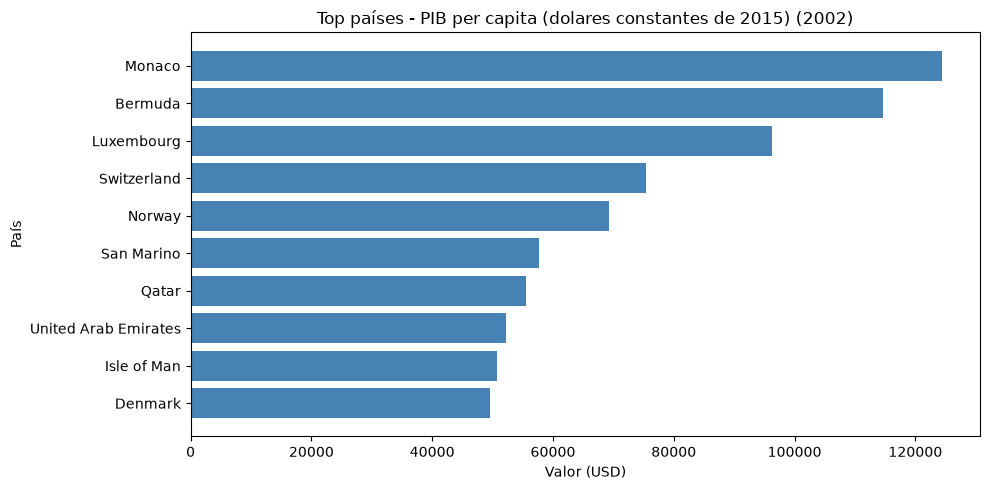

In [ ]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2002

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


**Interpretación:**

*(Escribe aquí tu respuesta)*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*(Escribe aquí tu conclusión)*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
